/tmp/ipykernel_2920/2027103375.py:122: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(


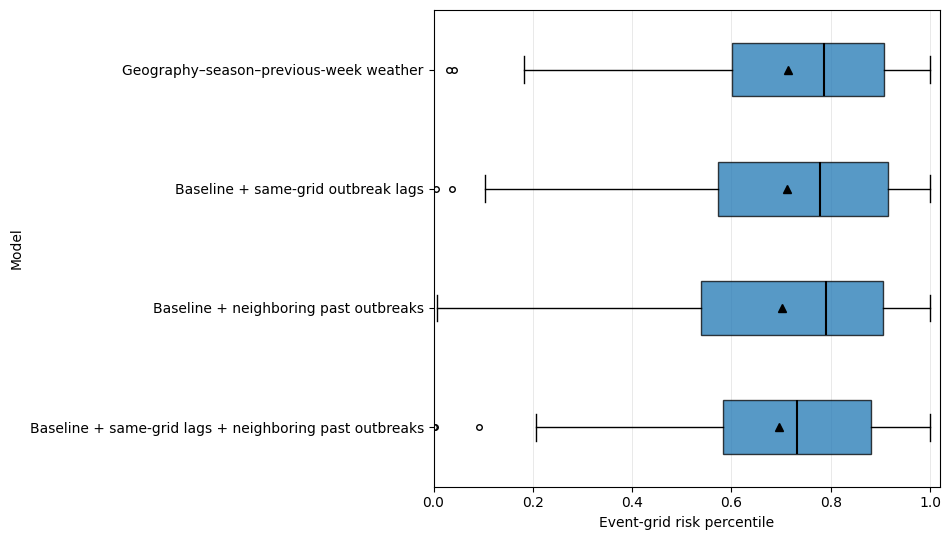

Using: 06_v2_rolling_event_cases_previous_week_weather.csv
Saved: figure2_event_percentile_previous_week_weather.png
Saved: figure2_event_percentile_previous_week_weather.pdf


,events,mean,median,minimum,maximum
model_name,,,,,
geo_season_previous_week_weather,61,0.713277,0.786196,0.032052,1.0
geo_season_previous_week_weather_same_grid_lags,61,0.712376,0.778729,0.005463,1.0
geo_season_previous_week_weather_neighbor_past,61,0.702353,0.789474,0.006920,1.0
geo_season_previous_week_weather_lags_neighbor_past,61,0.695042,0.732653,0.001457,1.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Figure 2: Event-grid risk percentile distributions by model
# Previous-week weather rolling evaluation
# ============================================================

candidate_paths = [
    Path(
        "/content/drive/MyDrive/avian_influenza_project/"
        "processed/model_outputs_riskmap_eval/"
        "06_v2_rolling_event_cases_previous_week_weather.csv"
    ),
    Path(
        "06_v2_rolling_event_cases_previous_week_weather.csv"
    ),
]

input_path = next(
    (
        path
        for path in candidate_paths
        if path.exists()
    ),
    None,
)

if input_path is None:
    raise FileNotFoundError(
        "Updated rolling event cases were not found.\n"
        "Run "
        "06_v2_rolling_riskmap_evaluation_previous_week_weather_final.ipynb "
        "first.\nChecked:\n"
        + "\n".join(
            str(path)
            for path in candidate_paths
        )
    )

event_df = pd.read_csv(input_path)

model_order = [
    "geo_season_previous_week_weather",
    "geo_season_previous_week_weather_same_grid_lags",
    "geo_season_previous_week_weather_neighbor_past",
    "geo_season_previous_week_weather_lags_neighbor_past",
]

model_labels = {
    "geo_season_previous_week_weather": (
        "Geography–season–"
        "previous-week weather"
    ),
    "geo_season_previous_week_weather_same_grid_lags": (
        "Baseline + same-grid outbreak lags"
    ),
    "geo_season_previous_week_weather_neighbor_past": (
        "Baseline + neighboring past outbreaks"
    ),
    "geo_season_previous_week_weather_lags_neighbor_past": (
        "Baseline + same-grid lags + "
        "neighboring past outbreaks"
    ),
}

required_cols = {
    "model_name",
    "risk_percentile",
    "split_name",
}
missing = required_cols - set(
    event_df.columns
)
if missing:
    raise ValueError(
        f"Missing required columns: {sorted(missing)}"
    )

event_df["risk_percentile"] = pd.to_numeric(
    event_df["risk_percentile"],
    errors="coerce",
)
plot_df = event_df[
    event_df["model_name"].isin(
        model_order
    )
].dropna(
    subset=["risk_percentile"]
).copy()

counts = (
    plot_df.groupby("model_name")
    .size()
    .reindex(model_order)
)

if not counts.eq(61).all():
    raise ValueError(
        "Each model must contain 61 pooled outbreak events.\n"
        f"Observed:\n{counts}"
    )

data = [
    plot_df.loc[
        plot_df["model_name"] == model,
        "risk_percentile",
    ].to_numpy()
    for model in model_order
]
labels = [
    model_labels[model]
    for model in model_order
]

fig, ax = plt.subplots(
    figsize=(9.6, 5.5)
)

boxplot = ax.boxplot(
    data,
    vert=False,
    labels=labels,
    showmeans=True,
    patch_artist=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 6,
    },
    medianprops={
        "color": "black",
        "linewidth": 1.5,
    },
    boxprops={
        "edgecolor": "black",
        "linewidth": 1.0,
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.0,
    },
    capprops={
        "color": "black",
        "linewidth": 1.0,
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 4,
        "linestyle": "none",
    },
)

for patch in boxplot["boxes"]:
    patch.set_alpha(0.75)

#rng = np.random.default_rng(42)
#for y_position, values in enumerate(
#    data,
#    start=1,
#):
#    jitter = rng.normal(
#        loc=y_position,
#        scale=0.045,
#        size=len(values),
#    )
#    ax.scatter(
#        values,
#        jitter,
#        s=22,
#        alpha=0.45,
#        edgecolors="black",
#        linewidths=0.3,
#        zorder=3,
#    )

ax.set_xlabel(
    "Event-grid risk percentile"
)
ax.set_ylabel("Model")
ax.set_xlim(0, 1.02)
ax.grid(
    axis="x",
    linewidth=0.4,
    alpha=0.5,
)
ax.invert_yaxis()

plt.tight_layout()

output_dir = input_path.parent
png_path = (
    output_dir
    / "figure2_event_percentile_previous_week_weather.png"
)
pdf_path = (
    output_dir
    / "figure2_event_percentile_previous_week_weather.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    pdf_path,
    bbox_inches="tight",
)
plt.show()

summary = (
    plot_df.groupby("model_name")[
        "risk_percentile"
    ]
    .agg(
        events="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reindex(model_order)
)

print("Using:", input_path)
print("Saved:", png_path)
print("Saved:", pdf_path)
display(summary)